In [1]:
import numpy as np

ver = 'GRU'  # GRU or LSTM

date = "250804"
rnn_folder = f"D:/Python_TK_3/datas/{date}_DL"
shap_number = "VisStim_evoked_01"

look_frame = 10

shap_vals = np.load(f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_shap_values.npy")

print(shap_vals.shape)

(192, 11, 67584)


In [2]:
roi_number = []
for ic in range(shap_vals.shape[2]):
    roi_number.append(f"IC{ic+1}")

print(roi_number)

['IC1', 'IC2', 'IC3', 'IC4', 'IC5', 'IC6', 'IC7', 'IC8', 'IC9', 'IC10', 'IC11', 'IC12', 'IC13', 'IC14', 'IC15', 'IC16', 'IC17', 'IC18', 'IC19', 'IC20', 'IC21', 'IC22', 'IC23']


In [2]:
fs = 20

# 初期値
start_value = -0.5

# 増加量
increment = 1/fs

# 繰り返し回数
count = look_frame+1

# リストを生成
t = [start_value + i * increment for i in range(count)]

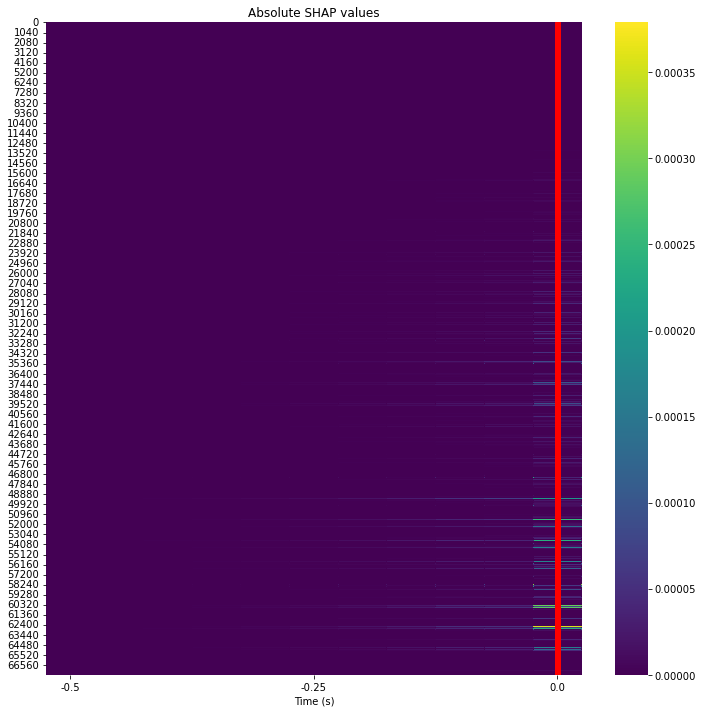

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

def show_shap_abs_mean(shap_val):
    s = np.mean(np.abs(shap_val), axis=0).reshape([look_frame+1, shap_vals.shape[2]])
    plt.figure(figsize=(12, 12))
    sns.heatmap(s.transpose(),cmap='viridis')
    #plt.xticks( numpy.arange(0.5,2*look_frame+1.5), numpy.arange(-look_frame,look_frame+1), fontsize=12)
    #plt.xticks(np.arange(0.5,look_frame+1.5, 5), np.arange(-int(look_frame/fs), 1/fs, 5))
    # Tickの位置
    ticks = np.arange(0.5, look_frame + 1.0, 5)
    # 同じ数のラベルを作る
    labels = np.linspace(start_value, 0, len(ticks))
    plt.xticks(ticks, labels)
    #plt.yticks( np.arange(0.5, shap_vals.shape[2]+0.5), roi_number, rotation=0)
    plt.axvspan(10.45, 10.55, color='red', alpha=1)
    plt.title("Absolute SHAP values")
    plt.xlabel("Time (s)")
    #plt.ylabel("IC #")
    plt.show()

show_shap_abs_mean(shap_vals)

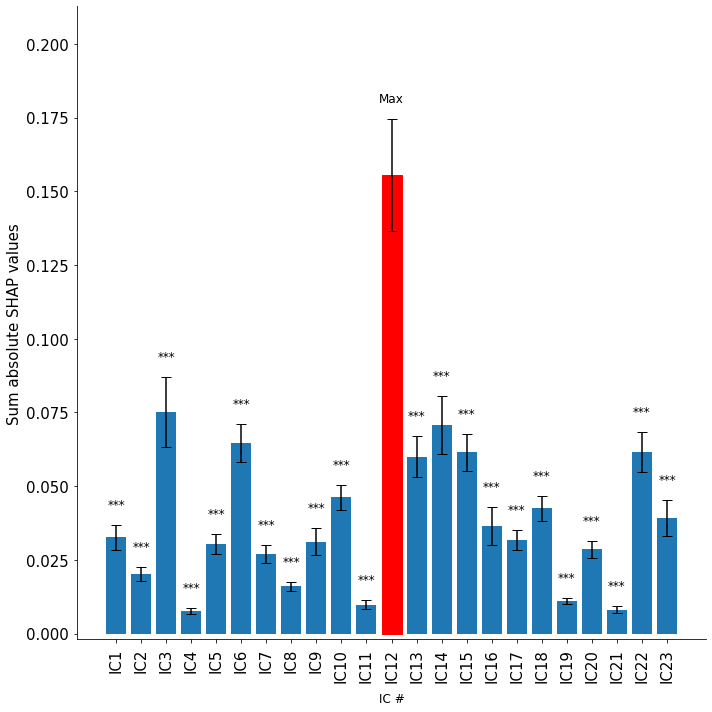

最も平均値が高いグループ: Group IC12
   Group      Mean       SEM       P-value  Corrected P-value  Significant
0    IC1  0.032579  0.004190  2.244045e-08       2.917258e-07         True
1    IC2  0.020159  0.002322  1.182365e-10       2.128258e-09         True
2    IC3  0.075124  0.011898  1.050781e-04       7.355465e-04         True
3    IC4  0.007620  0.001068  4.793054e-18       1.054472e-16         True
4    IC5  0.030456  0.003350  3.597090e-08       3.956799e-07         True
5    IC6  0.064691  0.006343  1.711238e-03       3.422475e-03         True
6    IC7  0.027029  0.003119  8.253738e-09       1.242246e-07         True
7    IC8  0.015965  0.001392  6.843021e-11       1.300174e-09         True
8    IC9  0.031086  0.004588  3.743216e-09       6.363467e-08         True
9   IC10  0.046160  0.004287  2.220680e-05       1.776544e-04         True
10  IC11  0.009824  0.001426  7.921872e-17       1.663593e-15         True
11  IC12  0.155623  0.019033  1.000000e+00       1.000000e+00        False


In [5]:
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import multipletests
import pandas as pd
import matplotlib.pyplot as plt



predata = np.sum(np.abs(shap_vals), axis= 1).transpose()
data = predata.tolist()

group_names = [str(i) for i in range(1, predata.shape[0]+1)]
#group_names = areanames
# 平均値と標準誤差の計算
means = [np.mean(group) for group in data]
sems = [stats.sem(group) for group in data]

# 平均値が最も高いグループを特定
max_mean_index = np.argmax(means)

# Wilcoxon rank-sum testの実行
p_values = []
for i, group in enumerate(data):
    if i != max_mean_index:
        _, p = stats.ranksums(data[max_mean_index], group)
        p_values.append(p)
    else:
        p_values.append(1)  # 最大平均値のグループ自身との比較のため

# Holm補正の適用
_, p_corrected, _, _ = multipletests(p_values, method='holm')

# グラフの作成
plt.figure(figsize=(10, 10))
bars = plt.bar(group_names, means, yerr=sems, capsize=5)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.xlabel("IC #", fontsize=12, labelpad=10)  # ラベルのパディングを増やす
plt.ylabel("Sum absolute SHAP values", fontsize=15)

offset1 = 0.03 * max(abs(np.array(means)))
offset2 = 0.12 * max(abs(np.array(means)))

# 有意差のあるグループに*を付ける
for i, (p, bar) in enumerate(zip(p_corrected, bars)):
    if p>=0.05 and i != max_mean_index:
        mean = means[i]
        err = sems[i]
        if mean >= 0:
            height = mean + err + offset1
            va = 'bottom'
        else:
            height = mean - err - offset2
            va = 'top'
        plt.text(bar.get_x() + bar.get_width()/2, height, 'n.s.',
                 ha='center', va='bottom', fontsize=12)
    if p < 0.05 and p>=0.01 and i != max_mean_index:
        mean = means[i]
        err = sems[i]
        if mean >= 0:
            height = mean + err + offset1
            va = 'bottom'
        else:
            height = mean - err - offset2
            va = 'top'
        plt.text(bar.get_x() + bar.get_width()/2, height, '*',
                 ha='center', va='bottom', fontsize=12)
    if p < 0.01 and p>=0.005 and i != max_mean_index:
        mean = means[i]
        err = sems[i]
        if mean >= 0:
            height = mean + err + offset1
            va = 'bottom'
        else:
            height = mean - err - offset2
            va = 'top'
        plt.text(bar.get_x() + bar.get_width()/2, height, '**',
                 ha='center', va='bottom', fontsize=12)
    if p < 0.005 and i != max_mean_index:
        mean = means[i]
        err = sems[i]
        if mean >= 0:
            height = mean + err + offset1
            va = 'bottom'
        else:
            height = mean - err - offset2
            va = 'top'
        plt.text(bar.get_x() + bar.get_width()/2, height, '***',
                 ha='center', va='bottom', fontsize=12)
        

# 最大平均値のグループを強調
bars[max_mean_index].set_color('red')
max_mean = means[max_mean_index]
max_sem = sems[max_mean_index]
if max_mean >= 0:
    max_label_height = max_mean + max_sem + offset1
    max_label_va = 'bottom'
else:
    max_label_height = max_mean - max_sem - offset2
    max_label_va = 'top'
plt.text(max_mean_index, max_label_height, 'Max',
         ha='center', va=max_label_va, fontsize=12)

# y軸の範囲を調整して、マークが見切れないようにする
y_min = min(means) - max(sems) * 3
y_max = max(means) + max(sems) * 3
#plt.ylim(y_min, y_max)
plt.ylim(-0.002, y_max)

plt.xticks(range(predata.shape[0]), roi_number, rotation=90)
plt.tick_params(axis='x', which='major', labelsize=15, pad=5)
plt.tick_params(axis='y', which='major', labelsize=15, pad=5)

# x軸に目盛りを追加
plt.tight_layout()
plt.show()

# 結果の表示（オプション）
results = pd.DataFrame({
    'Group': roi_number,
    'Mean': means,
    'SEM': sems,
    'P-value': p_values,
    'Corrected P-value': p_corrected,
    'Significant': p_corrected < 0.05
})

print("最も平均値が高いグループ: Group {}".format(roi_number[max_mean_index]))
print(results)

# 'Significant'がFalseなgroupをリストにする
non_significant_groups = results[results['Significant'] == False]['Group'].tolist()

print("最重要ROIs")
print(non_significant_groups)

In [20]:
means_array = np.array(means)

# 配列Bの値をインデックスとして、対応するCの値に変換するための辞書を作成
#value_map = dict(zip(roi_number.astype(int), means_array))
value_map = dict(zip(np.arange(1, roi_number.shape[0]+1).astype(int), means_array))

# 配列Aの値を変更する処理
atlas_int = atlas.astype(int)

# 1. 配列Bの値をキーとして配列Cの値を取得し、存在しない場合は0を返す
#mapped_values = np.vectorize(value_map.get)(atlas_int, 0)
mapped_values = np.array([[value_map.get(val, 0) for val in row] for row in atlas_int])



#plt.imshow(mapped_values)
#plt.show()

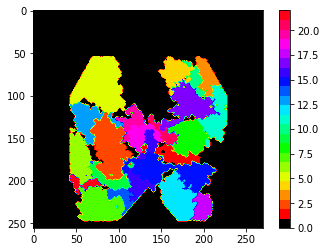

In [21]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

#0番：背景（黒）、1〜36番：レイヤー1〜36の色
base_cmap = plt.cm.get_cmap('hsv', roi_number.shape[0])  # HSVを使って36色生成
colors = ['black'] + [base_cmap(i) for i in range(roi_number.shape[0])]
cmap = ListedColormap(colors)

plt.imshow(atlas_int, cmap=cmap)
plt.colorbar()
plt.show()

In [7]:
np.save(f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_shap_value_mean.npy", means_array)

NameError: name 'means_array' is not defined

In [3]:
import numpy as np

date = "250523"
rnn_folder = f"D:/Python_TK_3/datas/{date}_DL"
shap_number = "ssStim_AllTrace_02"

look_frame = 40

In [4]:
weights = np.load(f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_pca_weights.npy")

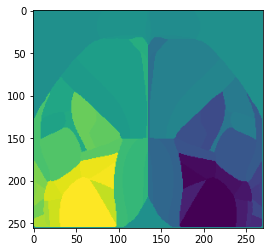

In [5]:
#means_array = np.array(means)

# 配列Bの値をインデックスとして、対応するCの値に変換するための辞書を作成
value_map = dict(zip(roi_number.astype(int), weights[0]))

# 配列Aの値を変更する処理
atlas_int = atlas.astype(int)

# 1. 配列Bの値をキーとして配列Cの値を取得し、存在しない場合は0を返す
#mapped_values = np.vectorize(value_map.get)(atlas_int, 0)
mapped_values = np.array([[value_map.get(val, 0) for val in row] for row in atlas_int])

import matplotlib.pyplot as plt
plt.imshow(atlas_int)
plt.show()

#plt.imshow(mapped_values)
#plt.show()

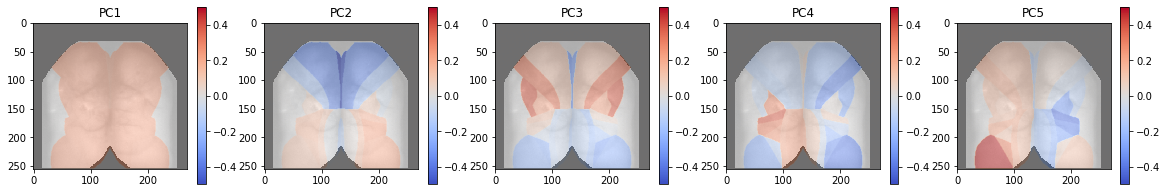

In [8]:
import matplotlib.pyplot as plt

atlas_int = atlas.astype(int)

plt.figure(figsize=(20, 15))  # 幅12インチ、高さ8インチのFigureを作成

for comp in range(weights.shape[0]):  # Start from 1 and end at 15 (inclusive)
  plt.subplot(4, 5, comp+1)
  value_map = dict(zip(roi_number.astype(int), weights[comp]))
  mapped_values = np.array([[value_map.get(val, 0) for val in row] for row in atlas_int])
  #plt.imshow(mapped_values, cmap='viridis')
  plt.imshow(mapped_values, cmap="coolwarm", vmin=-0.5, vmax=0.5)
  #plt.imshow(mapped_values, cmap="coolwarm")
  plt.colorbar()
  plt.imshow(tifdata, cmap='gist_gray', alpha=0.5, interpolation='none')
  plt.title(f"PC{comp+1}")
  # ... rest of your code


plt.show()

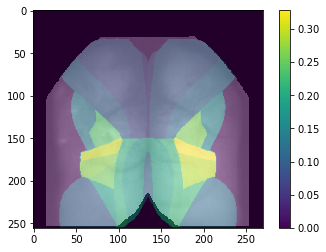

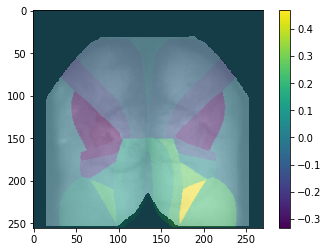

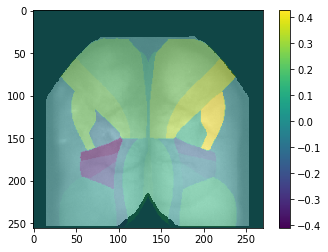

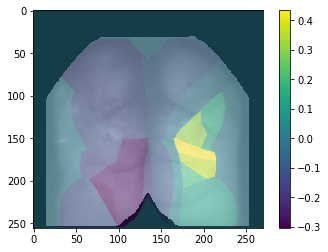

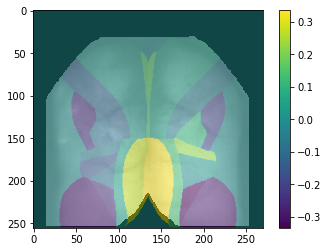

In [7]:

atlas_int = atlas.astype(int)

for comp in range(weights.shape[0]):
    value_map = dict(zip(roi_number.astype(int), weights[comp]))
    mapped_values = np.array([[value_map.get(val, 0) for val in row] for row in atlas_int])

    plt.imshow(mapped_values, cmap='viridis')
    plt.colorbar()
    plt.imshow(tifdata, cmap='gist_gray', alpha=0.5, interpolation='none')
    plt.show()

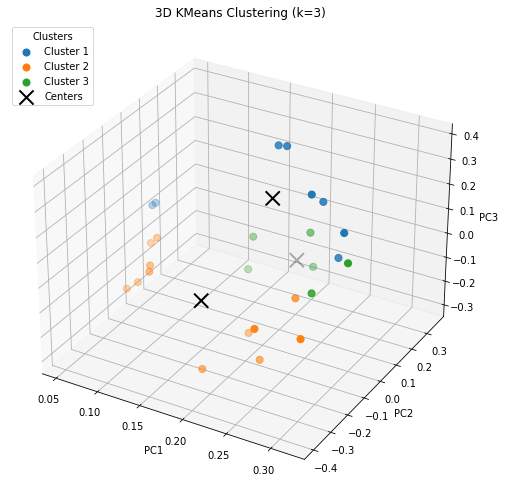

In [16]:
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- ２．点群データに変換 ---
points = weights.T  # shape = (26, 3)

# --- ３．KMeans の実行 ---
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42).fit(points)
labels = kmeans.labels_            # shape=(26,), 各点のクラスタ番号
centers = kmeans.cluster_centers_  # shape=(3,3), 各クラスタの重心

# --- ４．結果の可視化 ---
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')

# カラーマップを取得
cmap = plt.get_cmap('tab10')

# 各クラスタごとにプロットし、ラベルをつける
for cluster_id in range(n_clusters):
    idx = (labels == cluster_id)
    ax.scatter(
        points[idx, 0], points[idx, 1], points[idx, 2],
        color=cmap(cluster_id),
        s=50,
        label=f'Cluster {cluster_id+1}'
    )

# 重心を黒い×マーカーでプロット
ax.scatter(
    centers[:, 0], centers[:, 1], centers[:, 2],
    c='k', marker='x', s=200, linewidths=2, label='Centers'
)

# 軸ラベル・タイトル
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title(f'3D KMeans Clustering (k={n_clusters})')

# 凡例を表示（どの色がどのクラスタか一目で分かる）
ax.legend(loc='upper left', title='Clusters')

plt.tight_layout()
plt.show()


In [12]:
# --- indicator 行列の作成 ---
n_points = points.shape[0]   # 26
indicator = np.zeros((n_clusters, n_points), dtype=int)

for i, lbl in enumerate(labels):
    indicator[lbl, i] = 1

# 結果確認
print(indicator.shape)  # (3, 26)
print(indicator)

(3, 26)
[[0 1 0 0 0 0 0 1 1 1 1 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0]
 [0 0 1 0 1 1 1 0 0 0 0 1 1 1 1 0 0 0 0 1 1 1 0 1 0 0]
 [1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 1 1]]


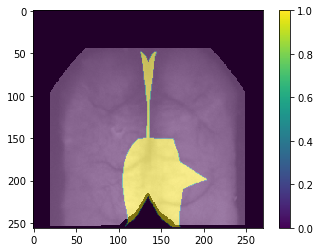

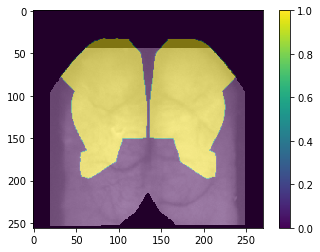

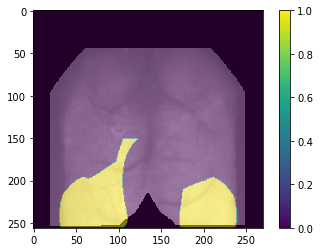

In [14]:
atlas_int = atlas.astype(int)

for cluster in range(indicator.shape[0]):
    value_map = dict(zip(roi_number.astype(int), indicator[cluster]))
    mapped_values = np.array([[value_map.get(val, 0) for val in row] for row in atlas_int])

    plt.imshow(mapped_values, cmap='viridis')
    plt.colorbar()
    plt.imshow(tifdata, cmap='gist_gray', alpha=0.5, interpolation='none')
    plt.show()

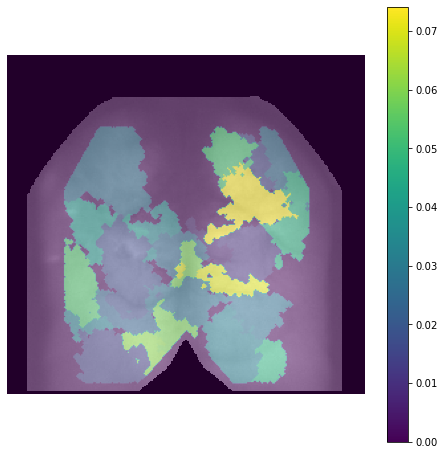

In [23]:
plt.figure(figsize=(8,8))

plt.imshow(mapped_values, cmap='viridis')
plt.colorbar()
plt.imshow(tifdata, cmap='gist_gray', alpha=0.5, interpolation='none')
plt.axis('off')
plt.show()